<a href="https://colab.research.google.com/github/2303A51317/AIML_2303A51317/blob/main/2303A51317_Batch_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Prediction of Absenteeism of Employees in Courier Company

1. Identify the top 5 reasons for absenteeism at work

2. Identify the Day of week with most absenteeism at work

3. Find the max and min age of employees of company

4. Name the seasons when absenteeism was most

5. Identify the highest educational qualification of the employees.

6. Apply either Classification Model or Clustering Model to evaluate the dataset

Importing the libraries

In [21]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Extend the dataset with additional columns
np.random.seed(42)
n = 200  # Number of employees


In [ ]:
data = {
    "EmployeeID": [f"E{str(i).zfill(4)}" for i in range(1, n+1)],
    "Age": np.random.randint(22, 60, size=n),
    "Gender": np.random.choice(["Male", "Female"], size=n),
    "Department": np.random.choice(["Operations", "Delivery", "Management", "Customer Service"], size=n),
    "JobRole": np.random.choice(["Courier", "Manager", "Driver", "Support Staff"], size=n),
    "YearsAtCompany": np.random.randint(1, 20, size=n),
    "Workload (hours)": np.random.randint(20, 60, size=n),
    "SickLeavesTaken": np.random.randint(0, 15, size=n),
    "VacationLeavesTaken": np.random.randint(0, 10, size=n),
    "LastAppraisalScore": np.random.uniform(2.0, 5.0, size=n).round(2),
    "DistanceFromHome": np.random.randint(1, 50, size=n),
    "Absenteeism (hours)": np.random.randint(0, 100, size=n),
    "AbsenceReason": np.random.choice(["Illness", "Family Issue", "Personal Work", "Transportation", "Weather"], size=n),
    "DayOfWeek": np.random.choice(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"], size=n),
    "Season": np.random.choice(["Spring", "Summer", "Autumn", "Winter"], size=n),
    "Education": np.random.choice(["High School", "Bachelor's", "Master's", "PhD"], size=n)
}


In [ ]:
df = pd.DataFrame(data)


In [ ]:
df.to_csv("Extended_Employee_Absenteeism.csv", index=False)


1: Identify the top 5 reasons for absenteeism at work

In [ ]:
top_reasons = df["AbsenceReason"].value_counts().head(5)
print("Top 5 Reasons for Absenteeism:")
print(top_reasons)


Top 5 Reasons for Absenteeism:
AbsenceReason
Transportation    48
Family Issue      44
Weather           40
Illness           37
Personal Work     31
Name: count, dtype: int64


Question 2: Identify the day of the week with most absenteeism


In [ ]:
day_with_most_absenteeism = df["DayOfWeek"].value_counts().idxmax()
print(f"\nDay with the most absenteeism: {day_with_most_absenteeism}")



Day with the most absenteeism: Friday


# Question 3: Find the max and min age of employees


In [ ]:
max_age = df["Age"].max()
min_age = df["Age"].min()
print(f"\nMaximum Age: {max_age}, Minimum Age: {min_age}")



Maximum Age: 59, Minimum Age: 22


# Question 4: Name the season when absenteeism was the most


In [ ]:
season_with_most_absenteeism = df["Season"].value_counts().idxmax()
print(f"\nSeason with the most absenteeism: {season_with_most_absenteeism}")




Season with the most absenteeism: Winter


# Question 5: Identify the highest educational qualification

In [ ]:
#Identify highest educational qualification of the employees
highest_qualification = df['Education'].value_counts().idxmax()
print(f"Highest educational qualification: {highest_qualification}")


Highest educational qualification: PhD



# Question 6: Apply clustering model to evaluate absenteeism

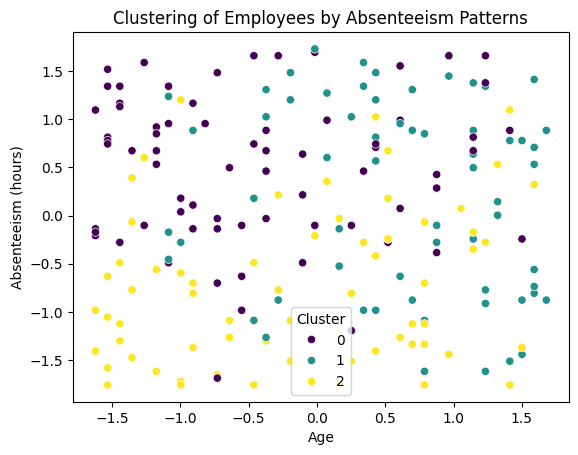

In [ ]:
# Normalize data for clustering
from sklearn.preprocessing import StandardScaler

features = df[["Age", "Workload (hours)", "SickLeavesTaken", "VacationLeavesTaken", "Absenteeism (hours)"]]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(features_scaled)

# Visualize clustering results
sns.scatterplot(
    x=features_scaled[:, 0], y=features_scaled[:, 4], hue=df["Cluster"], palette="viridis"
)
plt.xlabel("Age")
plt.ylabel("Absenteeism (hours)")
plt.title("Clustering of Employees by Absenteeism Patterns")
plt.show()